In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [2]:
sellers = pd.read_csv(RAW_DIR / "olist_sellers_dataset.csv")
order_items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")
reviews = pd.read_csv(RAW_DIR / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")

In [11]:
print(f"Sellers: {sellers.shape}")
print(f"Order_items: {order_items.shape}")

Sellers: (3095, 4)
Order_items: (112650, 7)


In [4]:
# 1. Tổng quan
print("\n=== TỔNG QUAN ===")
print(f"Số lượng nhà bán: {sellers['seller_id'].nunique()}")
print(f"Số lượng thành phố có seller: {sellers['seller_city'].nunique()}")
print(f"Số lượng bang: {sellers['seller_state'].nunique()}")


=== TỔNG QUAN ===
Số lượng nhà bán: 3095
Số lượng thành phố có seller: 611
Số lượng bang: 23


In [5]:
# 2. Top/Bottom seller theo doanh thu
seller_revenue = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False)

print("\n=== TOP 10 NHÀ BÁN DOANH THU CAO NHẤT ===")
print(seller_revenue.head(10).round(2))

print("\n=== TOP 10 NHÀ BÁN DOANH THU THẤP NHẤT ===")
print(seller_revenue.tail(10).round(2))



=== TOP 10 NHÀ BÁN DOANH THU CAO NHẤT ===
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

=== TOP 10 NHÀ BÁN DOANH THU THẤP NHẤT ===
seller_id
95cca791657aabeff15a07eb152d7841    9.99
c18309219e789960add0b2255ca4b091    9.90
0f94588695d71662beec8d883ffacf09    9.00
4965a7002cca77301c82d3f91b82e1a9    8.49
ad14615bdd492b01b0d97922e87cb87f    8.25
34aefe746cd81b7f3b23253ea28bef39    8.00
702835e4b785b67a084280efca355756    7.60
1fa2d3def6adfa70e58c276bb64fe5bb    6.90
77128dec4bec4878c37ab7d6169d6f26    6.50
cf6f6bc4df3999b9c6440f124fb2f687    

In [6]:
# 3. Top seller theo số lượng bán
seller_volume = order_items.groupby('seller_id')['order_id'].count().sort_values(ascending=False)

print("\n=== TOP 10 NHÀ BÁN BÁN CHẠY NHẤT ===")
print(seller_volume.head(10))


=== TOP 10 NHÀ BÁN BÁN CHẠY NHẤT ===
seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: order_id, dtype: int64


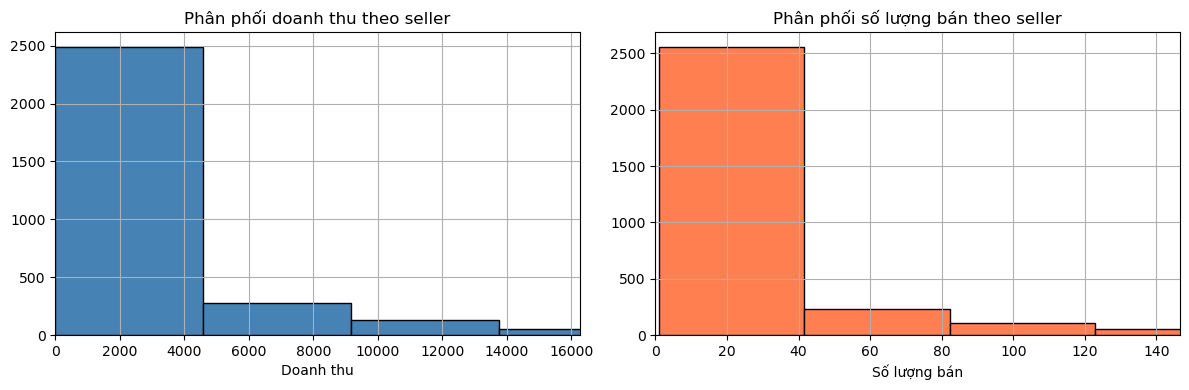


Thống kê doanh thu seller:
count      3095.000000
mean       4391.484233
std       13921.997192
min           3.500000
25%         208.850000
50%         821.480000
75%        3280.830000
max      229472.630000
Name: price, dtype: float64


In [7]:
# 4. Phân phối doanh thu seller
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
seller_revenue.hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Phân phối doanh thu theo seller')
plt.xlabel('Doanh thu')
plt.xlim(0, seller_revenue.quantile(0.95))

plt.subplot(1, 2, 2)
seller_volume.hist(bins=50, color='coral', edgecolor='black')
plt.title('Phân phối số lượng bán theo seller')
plt.xlabel('Số lượng bán')
plt.xlim(0, seller_volume.quantile(0.95))

plt.tight_layout()
plt.show()

print(f"\nThống kê doanh thu seller:")
print(seller_revenue.describe())

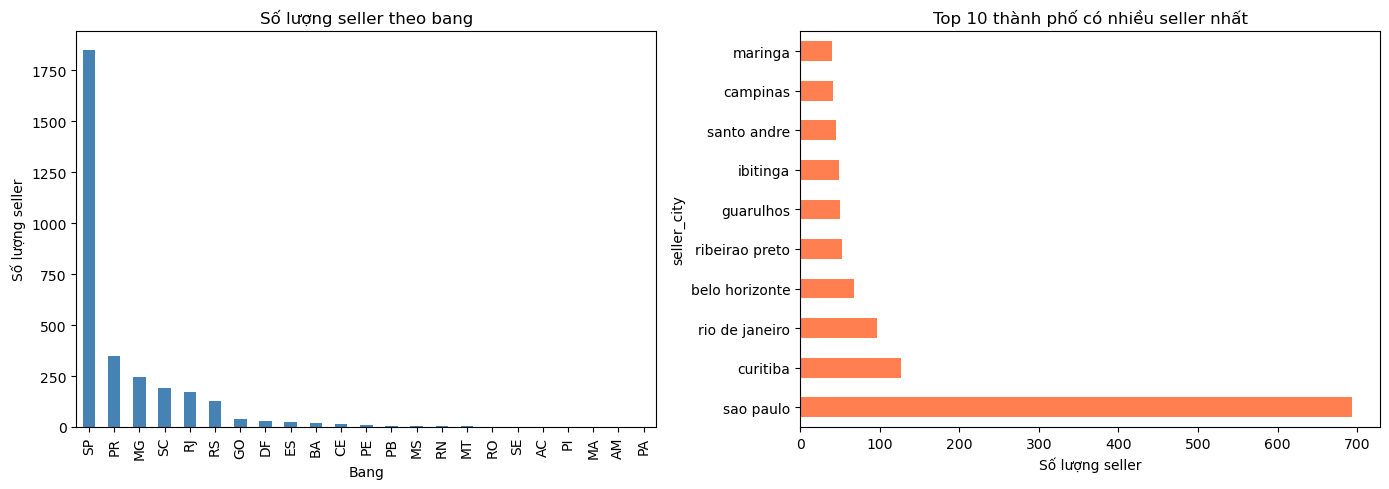


=== TOP 5 BANG CÓ NHIỀU SELLER NHẤT ===
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
Name: count, dtype: int64


In [8]:
# 5. Phân bố seller theo địa lý
seller_by_state = sellers['seller_state'].value_counts()
seller_by_city = sellers['seller_city'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seller_by_state.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Số lượng seller theo bang')
axes[0].set_xlabel('Bang')
axes[0].set_ylabel('Số lượng seller')

seller_by_city.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 thành phố có nhiều seller nhất')
axes[1].set_xlabel('Số lượng seller')

plt.tight_layout()
plt.show()

print("\n=== TOP 5 BANG CÓ NHIỀU SELLER NHẤT ===")
print(seller_by_state.head())

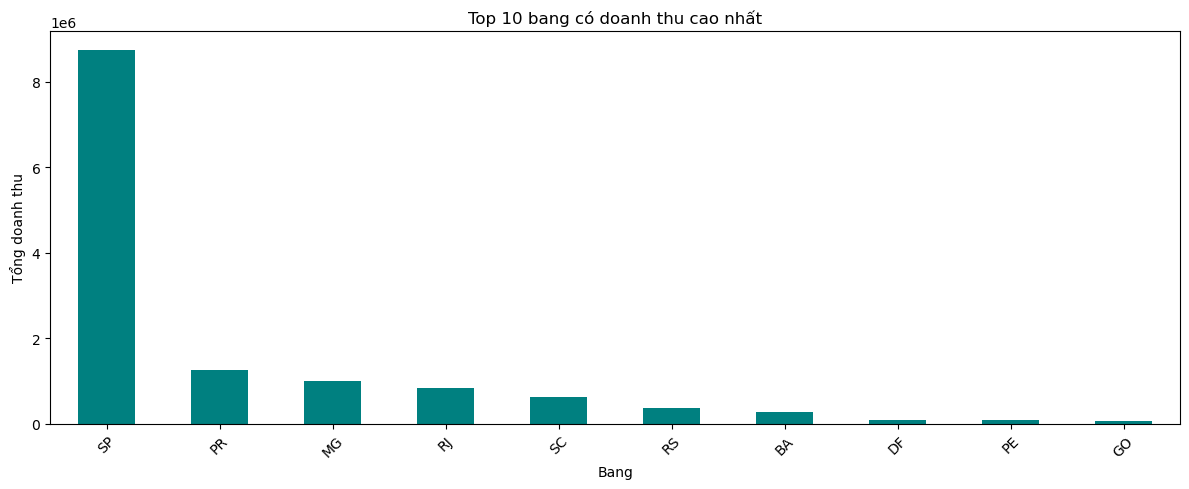


=== TOP 5 BANG DOANH THU CAO NHẤT ===
seller_state
SP    8753396.21
PR    1261887.21
MG    1011564.74
RJ     843984.22
SC     632426.07
Name: price, dtype: float64


In [13]:
# 6. Doanh thu theo địa lý 
# Merge trực tiếp
merged = order_items.merge(sellers, on='seller_id', how='left')

# Doanh thu theo bang
revenue_by_state = merged.groupby('seller_state')['price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
revenue_by_state.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 bang có doanh thu cao nhất')
plt.xlabel('Bang')
plt.ylabel('Tổng doanh thu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== TOP 5 BANG DOANH THU CAO NHẤT ===")
print(revenue_by_state.head())

In [14]:
# 7. Seller có rating cao nhất (kết hợp với reviews)
# Tính rating trung bình cho mỗi order (dựa trên order_id)
order_rating = reviews.groupby('order_id')['review_score'].mean()
order_with_seller = order_items[['order_id', 'seller_id']].drop_duplicates()
seller_rating = order_with_seller.merge(order_rating.reset_index(), on='order_id', how='left')
seller_avg_rating = seller_rating.groupby('seller_id')['review_score'].mean().sort_values(ascending=False)

print("\n=== TOP 10 NHÀ BÁN CÓ RATING CAO NHẤT ===")
print(seller_avg_rating.head(10))

print("\n=== TOP 10 NHÀ BÁN CÓ RATING THẤP NHẤT ===")
print(seller_avg_rating.tail(10))


=== TOP 10 NHÀ BÁN CÓ RATING CAO NHẤT ===
seller_id
feb793c88d836c3a75efa4b5a3465d70    5.0
003554e2dce176b5555353e4f3555ac8    5.0
cf6f6bc4df3999b9c6440f124fb2f687    5.0
5e25c632f9db6cfb8bc100421c2737b6    5.0
5e106d93b717c2682b9383da480364a1    5.0
5e063e85d44b0f5c3e6ec3131103a57e    5.0
6025c79c035c3d772133b8b8238463b2    5.0
04ee0ec01589969663ba5967c0e0bdc0    5.0
04843805947f0fc584fc1969b6e50fe7    5.0
044668ccd5316b12a7cf0d54a156e3e9    5.0
Name: review_score, dtype: float64

=== TOP 10 NHÀ BÁN CÓ RATING THẤP NHẤT ===
seller_id
62d977e2b2aee830de3e039a28490d12    1.0
c85d7b477a709c85a1e8b8f25aa1b270    1.0
c87abc38c8ed3240861729e1aeadf221    1.0
d1a5cc844736958c11b8efab9a2b4c87    1.0
001e6ad469a905060d959994f1b41e4f    1.0
20f0aeea30bc3b8c4420be8ced4226c0    NaN
3820c6537b3853be1a0687d5a60807ec    NaN
400f221ab83037c0ea78f1267da9624d    NaN
80ceebb4ee9b31afb6c6a916a574a1e2    NaN
bcd2d7510d58e293f20fad6438c1b314    NaN
Name: review_score, dtype: float64


In [15]:
# 8. Thống kê seller theo số lượng sản phẩm
seller_product_count = order_items.groupby('seller_id')['product_id'].nunique().sort_values(ascending=False)

print("\n=== TOP 10 NHÀ BÁN CÓ NHIỀU SẢN PHẨM NHẤT ===")
print(seller_product_count.head(10))


=== TOP 10 NHÀ BÁN CÓ NHIỀU SẢN PHẨM NHẤT ===
seller_id
4a3ca9315b744ce9f8e9374361493884    399
cca3071e3e9bb7d12640c9fbe2301306    322
d91fb3b7d041e83b64a00a3edfb37e4f    315
fa1c13f2614d7b5c4749cbc52fecda94    289
7142540dd4c91e2237acb7e911c4eba2    266
6560211a19b47992c3666cc44a7e94c0    256
da8622b14eb17ae2831f4ac5b9dab84a    222
ea8482cd71df3c1969d7b9473ff13abc    220
3d871de0142ce09b7081e2b9d1733cb1    202
7c67e1448b00f6e969d365cea6b010ab    198
Name: product_id, dtype: int64


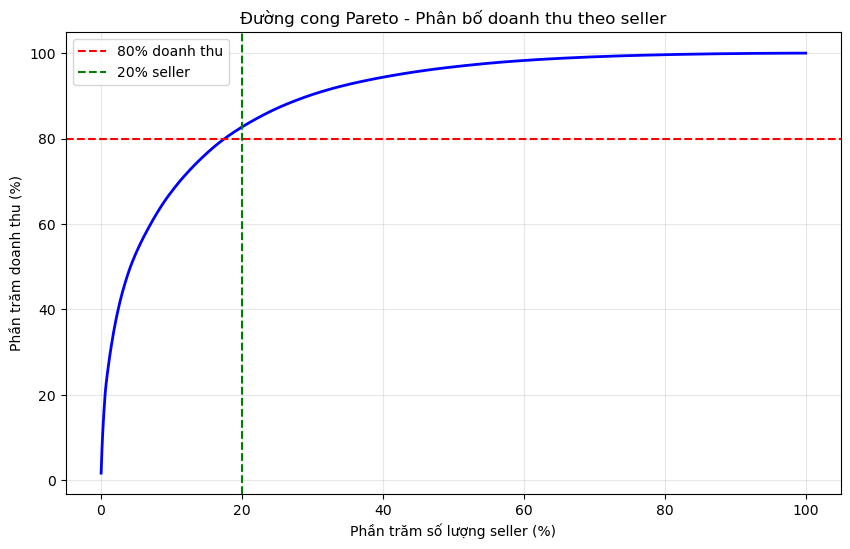

In [16]:
# 9. Phân tích Pareto (80/20)
# Sắp xếp doanh thu giảm dần và tính cumulative
seller_revenue_sorted = seller_revenue.sort_values(ascending=False)
cumulative_revenue = seller_revenue_sorted.cumsum() / seller_revenue_sorted.sum()
seller_count_pct = (np.arange(len(seller_revenue_sorted)) + 1) / len(seller_revenue_sorted) * 100

plt.figure(figsize=(10, 6))
plt.plot(seller_count_pct, cumulative_revenue * 100, 'b-', linewidth=2)
plt.axhline(y=80, color='r', linestyle='--', label='80% doanh thu')
plt.axvline(x=20, color='g', linestyle='--', label='20% seller')
plt.xlabel('Phần trăm số lượng seller (%)')
plt.ylabel('Phần trăm doanh thu (%)')
plt.title('Đường cong Pareto - Phân bố doanh thu theo seller')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Tính toán cụ thể
top_20_pct_count = int(len(seller_revenue_sorted) * 0.2)
revenue_top_20 = seller_revenue_sorted.head(top_20_pct_count).sum()
pct_revenue = revenue_top_20 / seller_revenue_sorted.sum() * 100

print(f"\n=== PHÂN TÍCH PARETO ===")
print(f"20% seller hàng đầu ({top_20_pct_count} seller) chiếm {pct_revenue:.1f}% tổng doanh thu")


=== PHÂN TÍCH PARETO ===
20% seller hàng đầu (619 seller) chiếm 82.7% tổng doanh thu


In [18]:
# 10. Kết luận
print("\n=== KẾT LUẬN ===")
print(f"✓ Tổng số seller: {len(sellers):,}")
print(f"✓ Doanh thu trung bình mỗi seller: ${seller_revenue.mean():.2f}")
print(f"✓ Doanh thu trung vị mỗi seller: ${seller_revenue.median():.2f}")
print(f"✓ Seller có doanh thu cao nhất: ${seller_revenue.max():.2f}")
print(f"✓ Bang có nhiều seller nhất: {seller_by_state.index[0]} ({seller_by_state.iloc[0]} seller)")
print(f"✓ Bang có doanh thu cao nhất: {revenue_by_state.index[0]}")
print(f"✓ {pct_revenue:.1f}% doanh thu đến từ {top_20_pct_count} seller (20% hàng đầu)")


=== KẾT LUẬN ===
✓ Tổng số seller: 3,095
✓ Doanh thu trung bình mỗi seller: $4391.48
✓ Doanh thu trung vị mỗi seller: $821.48
✓ Seller có doanh thu cao nhất: $229472.63
✓ Bang có nhiều seller nhất: SP (1849 seller)
✓ Bang có doanh thu cao nhất: SP
✓ 82.7% doanh thu đến từ 619 seller (20% hàng đầu)
